In [1]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, ToolMessage

load_dotenv()
if os.getenv("GROQ_API_KEY"):
    print("API Key Loaded")

API Key Loaded


In [2]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

### **Create Schema**

In [3]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List, add_messages]

### **Create The Nodes**

In [4]:
def welcome(schema:graph_schema) -> graph_schema:
    
    curr_message = schema['messages']
    
    response = llm.invoke(curr_message).content
    
    schema['messages'] = f"You Message Was {curr_message}. Here's my response: {response}"
    
    return schema

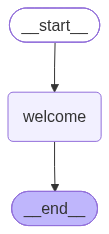

In [5]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("welcome",welcome)

graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

checkpoint = InMemorySaver() 

final_graph = graph.compile(checkpointer=checkpoint)
final_graph


In [7]:
response = final_graph.invoke(
    {"messages":"fahhhh"},
    {"configurable":{"thread_id":"rohit_lonkar"}}
)

for r in response['messages']:
    r.pretty_print()

================================ Human Message =================================

write a essay on ai
================================ Human Message =================================

You Message Was [HumanMessage(content='write a essay on ai', additional_kwargs={}, response_metadata={}, id='212d3e8b-f311-4c62-9e6f-207f383af93b')]. Here's my response: **Artificial Intelligence: Past, Present, and Future**

---

### Introduction  

Artificial Intelligence (AI) has moved from the realm of speculative fiction into the fabric of everyday life. From voice‑activated assistants that answer our questions to sophisticated algorithms that diagnose disease, AI is reshaping how societies function, economies grow, and individuals interact with technology. This essay surveys the evolution of AI, explores its current capabilities and applications, examines the ethical and societal challenges it raises, and looks ahead to the possibilities and responsibilities that the next generation of intelligent s